In [53]:
# all the necessary libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.model_selection as model_selection
import sklearn.preprocessing as pre
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
#models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [55]:
import pandas as pd 
import numpy as np 
import os 
import seaborn as sns 
import matplotlib.pyplot as plt 
import missingno as msno
# models
from sklearn.cluster import KMeans,DBSCAN
from scipy.cluster.hierarchy import linkage,dendrogram,cut_tree

In [57]:
main_df=pd.read_csv(r"C:\Users\Admin\Downloads\archive (4)\Placement_data_full_class.csv")
main_df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [59]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB


In [61]:
# to get the exact number of missing values in the column.
main_df.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [63]:
status_df = main_df[main_df['status'] == 'Not Placed' ]
print('Shape of the dataframe:', status_df.shape, sep ='\n', end ='\n\n')
print('Number of rows with status as Not Placed:', status_df['status' ].value_counts(), sep ='\n', end ='\n\n')
print('Number of rows with salary as zero:', status_df['salary' ].isnull().sum(), sep ='\n', end ='\n\n')

Shape of the dataframe:
(67, 15)

Number of rows with status as Not Placed:
status
Not Placed    67
Name: count, dtype: int64

Number of rows with salary as zero:
67



In [65]:
# segrigating all the numeric and categorical columns
num_cols = list(main_df.select_dtypes(exclude=['object']).columns)
cat_cols = list(main_df.select_dtypes(include=['object']).columns)
print('all the numeric cols: ',num_cols, end ='\n\n')
print('all the categorical cols:', cat_cols, end ='\n\n')

all the numeric cols:  ['sl_no', 'ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']

all the categorical cols: ['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex', 'specialisation', 'status']



In [67]:
main_df[num_cols].describe()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,108.000000,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,62.209324,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,54.500000,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,108.000000,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,161.500000,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,215.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


In [69]:
main_df[cat_cols].describe()

,gender,ssc_b,hsc_b,hsc_s,degree_t,workex,specialisation,status
count,215,215,215,215,215,215,215,215
unique,2,2,2,3,3,2,2,2
top,M,Central,Others,Commerce,Comm&Mgmt,No,Mkt&Fin,Placed
freq,139,116,131,113,145,141,120,148


In [71]:
# transform df 1
transform_df_1=main_df.drop(['salary'], axis=1)
transform_df_1.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed


In [73]:
num_cols.remove('salary')
num_cols

['sl_no', 'ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']

In [75]:
transform_df_1[num_cols].describe()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000
mean,108.000000,67.303395,66.333163,66.370186,72.100558,62.278186
std,62.209324,10.827205,10.897509,7.358743,13.275956,5.833385
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000
25%,54.500000,60.600000,60.900000,61.000000,60.000000,57.945000
50%,108.000000,67.000000,65.000000,66.000000,71.000000,62.000000
75%,161.500000,75.700000,73.000000,72.000000,83.500000,66.255000
max,215.000000,89.400000,97.700000,91.000000,98.000000,77.890000


In [77]:
def get_bins(df, col_name, bin_num):
    lower = df[col_name].min()
    upper = df[col_name].max()
    bins = np.linspace(lower,upper,bin_num+1)
    return bins
# example :
print(get_bins(transform_df_1, 'ssc_p', 3))

[40.89 57.06 73.23 89.4 ]


In [79]:
for i in (num_cols):
    transform_df_1[i]=pd.cut(transform_df_1[i],bins=get_bins(transform_df_1,i,2),labels=[0,1],include_lowest=True)
print(transform_df_1[num_cols].info())
transform_df_1[num_cols].head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   sl_no     215 non-null    category
 1   ssc_p     215 non-null    category
 2   hsc_p     215 non-null    category
 3   degree_p  215 non-null    category
 4   etest_p   215 non-null    category
 5   mba_p     215 non-null    category
dtypes: category(6)
memory usage: 2.1 KB
None


,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p
0,0,1,1,0,0,0
1,0,1,1,1,1,1
2,0,0,1,0,1,0
3,0,0,0,0,0,0
4,0,1,1,1,1,0


In [81]:
# converting the categorical columns to integer columns
for i in num_cols:
    transform_df_1[i] = transform_df_1[i].astype(int)
transform_df_1[num_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   sl_no     215 non-null    int32
 1   ssc_p     215 non-null    int32
 2   hsc_p     215 non-null    int32
 3   degree_p  215 non-null    int32
 4   etest_p   215 non-null    int32
 5   mba_p     215 non-null    int32
dtypes: int32(6)
memory usage: 5.2 KB


In [83]:
# converting the object type value into numeric 
labelencoder = pre.LabelEncoder()
for i in cat_cols:
    transform_df_1[i]=labelencoder.fit_transform(transform_df_1[i])
transform_df_1[cat_cols].head()

,gender,ssc_b,hsc_b,hsc_s,degree_t,workex,specialisation,status
0,1,1,1,1,2,0,1,1
1,1,0,1,2,2,1,0,1
2,1,0,0,0,0,0,0,1
3,1,0,0,2,2,0,1,0
4,1,0,0,1,0,0,0,1


In [85]:
print(transform_df_1.dtypes)

sl_no             int32
gender            int32
ssc_p             int32
ssc_b             int32
hsc_p             int32
hsc_b             int32
hsc_s             int32
degree_p          int32
degree_t          int32
workex            int32
etest_p           int32
specialisation    int32
mba_p             int32
status            int32
dtype: object


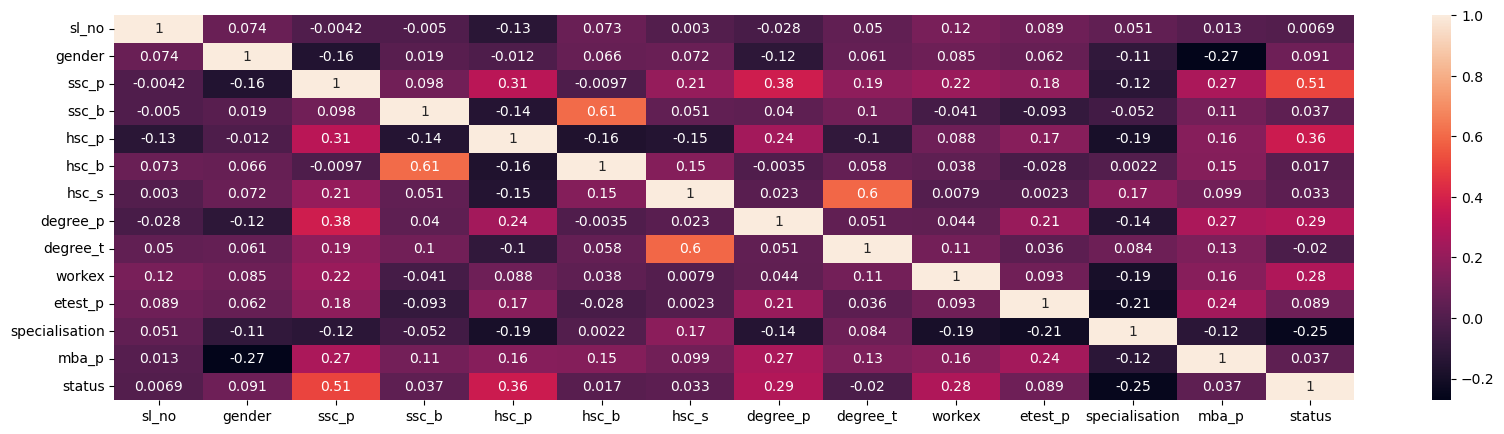

In [87]:
plt.figure(figsize=[20, 5])
sns.heatmap(transform_df_1.corr(), annot=True)
plt.show()

In [88]:
# from sklearn.feature_selection import mutual_info_classif
mutual_info = mutual_info_classif(transform_df_1.drop('status', axis =1),transform_df_1['status'])
mutual_info

array([0.        , 0.00708826, 0.12015669, 0.        , 0.07093549,
       0.        , 0.        , 0.06608886, 0.        , 0.03078053,
       0.00592427, 0.        , 0.        ])

In [89]:
mutual_info = pd.Series(mutual_info)
mutual_info.index = transform_df_1.drop('status', axis=1).columns
mutual_info.sort_values(ascending=False)

ssc_p             0.120157
hsc_p             0.070935
degree_p          0.066089
workex            0.030781
gender            0.007088
etest_p           0.005924
sl_no             0.000000
ssc_b             0.000000
hsc_b             0.000000
hsc_s             0.000000
degree_t          0.000000
specialisation    0.000000
mba_p             0.000000
dtype: float64

In [93]:
# select colums that have non-zero mutual information
sel_cols=[]
for i in range(len(mutual_info)):
    if(mutual_info[i]>0):
        sel_cols.append(mutual_info.index[i])
sel_cols.append('status')
print(sel_cols)

['gender', 'ssc_p', 'hsc_p', 'degree_p', 'workex', 'etest_p', 'status']


C:\Users\Admin\AppData\Local\Temp\ipykernel_11708\3893165209.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if(mutual_info[i]>0):


In [95]:
transform_df_2 = transform_df_1[sel_cols]
transform_df_2.head()


,gender,ssc_p,hsc_p,degree_p,workex,etest_p,status
0,1,1,1,0,0,0,1
1,1,1,1,1,1,1,1
2,1,0,1,0,0,1,1
3,1,0,0,0,0,0,0
4,1,1,1,1,0,1,1


In [97]:
# from sklearn.feature_selection import SelectKBest
transform_df_3 = transform_df_1
sel_top5 = SelectKBest(mutual_info_classif, k=5)
sel_top5.fit(transform_df_3.drop('status', axis = 1), transform_df_3['status'])

# to see which are the top5 columns:
list(transform_df_3.drop('status', axis=1).columns[sel_top5.get_support()])

['gender', 'ssc_p', 'hsc_p', 'degree_p', 'degree_t']

In [99]:
sel_top5 = list(transform_df_3.drop('status', axis=1).columns[sel_top5.get_support()])
sel_top5.append('status')
transform_df_3 = transform_df_3[sel_top5]
transform_df_3.head()

,gender,ssc_p,hsc_p,degree_p,degree_t,status
0,1,1,1,0,2,1
1,1,1,1,1,2,1
2,1,0,1,0,0,1
3,1,0,0,0,2,0
4,1,1,1,1,0,1


In [101]:
log_r = LogisticRegression()
X_train, X_test, y_train, y_test = model_selection.train_test_split(transform_df_1.drop('status', axis =1),
                                                                    transform_df_1['status'],test_size=0.25,
                                                                    stratify=transform_df_1['status'],
                                                                    random_state=42)
log_r.fit(X_train, y_train)
y_pred = log_r.predict(X_test)
confusion_matrix(y_test , y_pred)
# accuraccy of the model
# print('Score for transform_df_1: {:. 4f}'.format(accuracy_score(y_test , y_pred)))
print("Accuracy score",accuracy_score(y_test,y_pred))

Accuracy score 0.7962962962962963


# 4 Model Selection

In [104]:
def average_accuracy (main_df,model):
    skf=StratifiedKFold(n_splits=10,shuffle=True,random_state=12)
    all_accuracy = []
    X=main_df.drop("status",axis=1)
    y=main_df["status"]
    for train_index ,test_index in skf.split(X,y):
        X_train,X_test,y_train,y_test = X.iloc[train_index],X.loc[test_index],y.iloc[train_index],y.iloc[test_index]
        model.fit(X_train,y_train)
        all_accuracy.append(model.score(X_test,y_test))
    all_accuracy=sum(all_accuracy)/len(all_accuracy)
    return all_accuracy

# 4.1 Logistic Regression

In [107]:
transform_df_1 =main_df.drop(["salary"],axis=1)
transform_df_1.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed


In [109]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in transform_df_1.select_dtypes(include='object').columns:
    transform_df_1[col] = le.fit_transform(transform_df_1[col])

In [111]:
log_r = LogisticRegression()
print('transform_df_1: {:.4f}'.format(average_accuracy(transform_df_1,log_r)))
print('transform_df_2: {:.4f}'.format(average_accuracy(transform_df_2,log_r)))
print('transform_df_3: {:.4f}'.format(average_accuracy(transform_df_3,log_r)))

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

transform_df_1: 0.8738
transform_df_2: 0.8171
transform_df_3: 0.7894


In [113]:
print(transform_df_1.dtypes)

sl_no               int64
gender              int32
ssc_p             float64
ssc_b               int32
hsc_p             float64
hsc_b               int32
hsc_s               int32
degree_p          float64
degree_t            int32
workex              int32
etest_p           float64
specialisation      int32
mba_p             float64
status              int32
dtype: object


# 4.2 KNN

In [116]:
knn = KNeighborsClassifier(n_neighbors=5,algorithm='brute')
print('transform_df_1: {:.4f}'.format(average_accuracy(transform_df_1,knn)))
print('transform_df_2: {:.4f}'.format(average_accuracy(transform_df_2,knn)))
print('transform_df_3: {:.4f}'.format(average_accuracy(transform_df_3,knn)))

transform_df_1: 0.7907
transform_df_2: 0.7846
transform_df_3: 0.7803


# 4.3 Naive Bayes

In [119]:
nb = GaussianNB() # create a classifier
print('transform_df_1: {:.4f}'.format(average_accuracy(transform_df_1,nb)))
print('transform_df_2: {:.4f}'.format(average_accuracy(transform_df_2,nb)))
print('transform_df_3: {:.4f}'.format(average_accuracy(transform_df_3,nb)))

transform_df_1: 0.8314
transform_df_2: 0.7617
transform_df_3: 0.7894


# 4.4 SVM

In [122]:
svm = SVC(kernel='linear',class_weight={0:5, 1:5},probability=True)
print('transform_df_1: {:.4f}'.format(average_accuracy(transform_df_1,svm)))
print('transform_df_2: {:.4f}'.format(average_accuracy(transform_df_2,svm)))
print('transform_df_3: {:.4f}'.format(average_accuracy(transform_df_3,svm)))

transform_df_1: 0.8736
transform_df_2: 0.7946
transform_df_3: 0.7894


# 4.5 Decision Tree

In [124]:
dtree = DecisionTreeClassifier()
print('transform_df_1: {:.4f}'.format(average_accuracy(transform_df_1,dtree)))
print('transform_df_2: {:.4f}'.format(average_accuracy(transform_df_2,dtree)))
print('transform_df_3: {:.4f}'.format(average_accuracy(transform_df_3,dtree)))

transform_df_1: 0.7900
transform_df_2: 0.7613
transform_df_3: 0.7342


# 5 ENSEMBLE TECHNIQUE 

## 5.1 Bagging

In [126]:
#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(criterion='entropy',max_depth=9,random_state =121,max_leaf_nodes=3)
print("Random Forest Classifier: {:.4f}".format(average_accuracy(transform_df_1,rfc)))

Random Forest Classifier: 0.8180


In [ ]:
# Bagging Classifer
from sklearn.ensemble import BaggingClassifier

# logistic regression 
bag_lr=BaggingClassifier(estimator=LogisticRegression(class_weight={0:2,1:1}),n_estimators=100,random_state=121)

# KNN
bag_knn=BaggingClassifier(estimator=KNeighborsClassifier(n_neighbors=5,algorithm='brute'),n_estimators=100,random_state=121)

#Naive Bayes
bag_nb=BaggingClassifier(estimator=GaussianNB(),n_estimators=100,random_state=121)

#SVM
bag_svm=BaggingClassifier(estimator=SVC(kernel='linear',class_weight={0:5,1:5}),n_estimators=100,random_state=121)

#Decision Tree
bag_dt=BaggingClassifier(estimator=DecisionTreeClassifier(criterion='entropy',max_depth=9,random_state=121,max_leaf_nodes=3),n_estimators=100,random_state=121)


print("Bagging Logistic Regression: {:.4f}".format(average_accuracy(transform_df_1,bag_lr)))
print("Bagging KNeighborsClassifier: {:.4f}".format(average_accuracy(transform_df_1,bag_knn)))
print("Bagging Navie Bayes: {:.4f}".format(average_accuracy(transform_df_1,bag_nb)))
print("Bagging SVM: {:.4f}".format(average_accuracy(transform_df_1,bag_svm)))
print("Bagging Decision Tree Classifier: {:.4f}".format(average_accuracy(transform_df_1,bag_dt)))

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

In [45]:
# use voting classifier to simualte bagging 
from sklearn.ensemble import  VotingClassifier

voting_clf_hard=VotingClassifier(estimators=[('Logistic Regression',log_r),
                                           ('KNN',knn),
                                           ('NB',nb),
                                           ('SVM',svm),
                                           ('DecisionTree',dtree)],
                                voting='hard')
print('Voting Classifier Hard:{:.4f}'.format(average_accuracy(transform_df_1,voting_clf_hard)))



C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Voting Classifier Hard:0.8784


In [46]:
from sklearn.ensemble import  VotingClassifier
voting_clf_soft=VotingClassifier(estimators=[('Logistic Regression',log_r),
                                           ('KNN',knn),
                                           ('NB',nb),
                                           ('SVM',svm),
                                           ('DecisionTree',dtree)],
                                voting='soft')
print('Voting Classifier Soft:{:.4f}'.format(average_accuracy(transform_df_1,voting_clf_soft)))

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Voting Classifier Soft:0.8509


## 5.2 Boosting

In [164]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
# logistic regression 

ada_lr=AdaBoostClassifier(estimator=LogisticRegression(class_weight={0:2,1:1}),n_estimators=100,random_state=121,algorithm='SAMME')

# KNN
ada_knn=AdaBoostClassifier(estimator=KNeighborsClassifier(n_neighbors=5,algorithm='brute'),n_estimators=100,random_state=121,algorithm='SAMME')

#Naive Bayes
ada_nb=AdaBoostClassifier(estimator=GaussianNB(),n_estimators=100,random_state=121,algorithm='SAMME')

#SVM
ada_svm=AdaBoostClassifier(estimator=SVC(kernel='linear',class_weight={0:5,1:5},probability=True),n_estimators=100,random_state=121,algorithm='SAMME')

#Decision Tree
ada_dt=AdaBoostClassifier(estimator=DecisionTreeClassifier(criterion='entropy',max_depth=9,random_state=121,max_leaf_nodes=3),n_estimators=100,random_state=121,algorithm='SAMME')


print("Boosting Logistic Regression: {:.4f}".format(average_accuracy(transform_df_1,ada_lr)))
# print("Boosting KNeighborsClassifier: {:.4f}".format(average_accuracy(transform_df_1,ada_knn)))
print("Boosting Navie Bayes: {:.4f}".format(average_accuracy(transform_df_1,ada_nb)))
print("Boosting SVM: {:.4f}".format(average_accuracy(transform_df_1,ada_svm)))
print("Boosting Decision Tree Classifier: {:.4f}".format(average_accuracy(transform_df_1,ada_dt)))


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Boosting Logistic Regression: 0.8275
Boosting Navie Bayes: 0.8645
Boosting SVM: 0.8641
Boosting Decision Tree Classifier: 0.8597


In [144]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
#GradientBoostingClassifier

# logistic regression 
gb_lr=GradientBoostingClassifier(init=LogisticRegression(class_weight={0:2,1:1}),n_estimators=100,random_state=121)

# KNN
gb_knn=GradientBoostingClassifier(init=KNeighborsClassifier(n_neighbors=5,algorithm='brute'),n_estimators=100,random_state=121)

#Naive Bayes
gb_nb=GradientBoostingClassifier(init=GaussianNB(),n_estimators=100,random_state=121)

#SVM
gb_svm=GradientBoostingClassifier(init=SVC(kernel='linear',class_weight={0:5,1:5},probability=True),n_estimators=100,random_state=121)

#Decision Tree
gb_dt=GradientBoostingClassifier(init=DecisionTreeClassifier(criterion='entropy',max_depth=9,random_state=121,max_leaf_nodes=3),n_estimators=100,random_state=121)


print("Boosting Logistic Regression: {:.4f}".format(average_accuracy(transform_df_1,gb_lr)))
print("Boosting KNeighborsClassifier: {:.4f}".format(average_accuracy(transform_df_1,gb_knn)))
print("Boosting Navie Bayes: {:.4f}".format(average_accuracy(transform_df_1,gb_nb)))
print("Boosting SVM: {:.4f}".format(average_accuracy(transform_df_1,gb_svm)))
print("Boosting Decision Tree Classifier: {:.4f}".format(average_accuracy(transform_df_1,gb_dt)))

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Boosting Logistic Regression: 0.8554
Boosting KNeighborsClassifier: 0.8459
Boosting Navie Bayes: 0.8504
Boosting SVM: 0.8600
Boosting Decision Tree Classifier: 0.8271


In [146]:
# over sampling to test the actual result 
from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler
#before sampling
X=transform_df_1.drop('status',axis=1)
y=transform_df_1['status']

print('Before Sampling: ',pd.Series(y).value_counts(),end='\n\n',sep='\n')

#after sampling 
X, y= make_classification(n_samples=200, weights=[0.70], flip_y=0)
oversample=RandomOverSampler(sampling_strategy='minority')
X_over,y_over=oversample.fit_resample(X,y)
print('Over Sampling: ',pd.Series(y_over).value_counts(),sep='\n')

Before Sampling: 
status
1    148
0     67
Name: count, dtype: int64

Over Sampling: 
1    140
0    140
Name: count, dtype: int64


In [148]:
def KFold_accuracy(X,y,model):
    skf=StratifiedKFold(n_splits=10, shuffle=True,random_state=12)
    all_accuracy=[]
    for train_index,test_index in skf.split(X,y):
        X_train,X_test,y_train,y_test=X[train_index],X[test_index],y[train_index],y[test_index]
        model.fit(X_train,y_train)
        all_accuracy.append(model.score(X_test,y_test))
    all_accuracy=sum(all_accuracy)/len(all_accuracy)
    return all_accuracy

In [174]:
# Random Forest
print("Random Forest Classifier")
print("Random Forest Classifier: {:.4f}".format(KFold_accuracy(X_over,y_over,rfc)),end='\n\n')

# Bagging
print("Bagging")
print("Bagging Logistic Regression: {:.4f}".format(KFold_accuracy(X_over,y_over,bag_lr)))
print("Bagging KNeighborsClassifier: {:.4f}".format(KFold_accuracy(X_over,y_over,bag_knn)))
print("Bagging Navie Bayes: {:.4f}".format(KFold_accuracy(X_over,y_over,bag_nb)))
print("Bagging SVM: {:.4f}".format(KFold_accuracy(X_over,y_over,bag_svm)))
print("Bagging Decision Tree Classifier: {:.4f}".format(KFold_accuracy(X_over,y_over,bag_dt)),end='\n\n')

#Voting Classifier
print("Voting Classifier")
print('Voting Classifier Hard:{:.4f}'.format(KFold_accuracy(X_over,y_over,voting_clf_hard)))
print('Voting Classifier Soft:{:.4f}'.format(KFold_accuracy(X_over,y_over,voting_clf_soft)),end='\n\n')

#Boosting 
#Ada Boosting
print('Ada Boosting')
print("Boosting Logistic Regression: {:.4f}".format(KFold_accuracy(X_over,y_over,ada_lr)))
# print("Boosting KNeighborsClassifier: {:.4f}".format(KFold_accuracy(X_over,y_over,ada_knn)))
print("Boosting Navie Bayes: {:.4f}".format(KFold_accuracy(X_over,y_over,ada_nb)))
print("Boosting SVM: {:.4f}".format(KFold_accuracy(X_over,y_over,ada_svm)))
print("Boosting Decision Tree Classifier: {:.4f}".format(KFold_accuracy(X_over,y_over,ada_dt)),end='\n\n')

# Gradient Boosting
print("Gradient Boosting")
print("Boosting Logistic Regression: {:.4f}".format(KFold_accuracy(X_over,y_over,gb_lr)))
print("Boosting KNeighborsClassifier: {:.4f}".format(KFold_accuracy(X_over,y_over,gb_knn)))
print("Boosting Navie Bayes: {:.4f}".format(KFold_accuracy(X_over,y_over,gb_nb)))
print("Boosting SVM: {:.4f}".format(KFold_accuracy(X_over,y_over,gb_svm)))
print("Boosting Decision Tree Classifier: {:.4f}".format(KFold_accuracy(X_over,y_over,gb_dt)))

Random Forest Classifier
Random Forest Classifier: 0.9071

Bagging
Bagging Logistic Regression: 0.8964
Bagging KNeighborsClassifier: 0.8679
Bagging Navie Bayes: 0.8857
Bagging SVM: 0.8964
Bagging Decision Tree Classifier: 0.9143

Voting Classifier
Voting Classifier Hard:0.9036
Voting Classifier Soft:0.9071

Ada Boosting
Boosting Logistic Regression: 0.8821
Boosting Navie Bayes: 0.8964
Boosting SVM: 0.8643
Boosting Decision Tree Classifier: 0.9286

Gradient Boosting
Boosting Logistic Regression: 0.9321
Boosting KNeighborsClassifier: 0.9321
Boosting Navie Bayes: 0.9429
Boosting SVM: 0.9250
Boosting Decision Tree Classifier: 0.9500
